100%|██████████| 2500/2500 [00:02<00:00, 1048.88it/s]


color vision This browser does not support the video tag.


NameError: name 'frames' is not defined

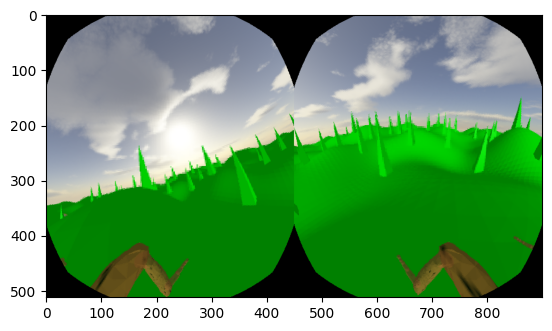

In [ ]:
from tqdm import trange
from flygym.compose import ActuatorType
from miniproject.simulation import MiniprojectSimulation
from submission.controller import Controller

import numpy as np
import matplotlib.pyplot as plt
import mediapy
    
can_walk = False

def detects_horizon_while_stopped(screenshot):
    can_walk = False

    #height_of_horizon = 0
    for i in range(5):
        if screenshot[260+i, 100][1] == 128:
            height_of_horizon = 261+i
            can_walk = True
            return height_of_horizon
    

sim = MiniprojectSimulation(level=2, seed=42)
controller = Controller(sim)

for k in trange(2500):
    joint_angles, adhesion = controller.step(sim)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion)

    sim.step()

    """
    if k>2000 & k%400==0:
        temp = detects_horizon_while_stopped(frames[-1])
        #print(temp)
    else:
        sim.step()
    """


mediapy.show_video(controller.frames, fps=sim.renderer.output_fps, title="color vision")
#sim.renderer.show_in_notebook()


###########################################################
#################### TEST ADRI ############################
###########################################################

############### debugg

plt.imshow(controller.frames[0])
print(controller.frames[0].shape)
#print(type(frames))
#for i in range(10):
#    print(frames[20][255+i, 100], i)

############### debugg